# Poking expressivity of shallow MLPs with ReLU activation functions.
Universal approximation theorems state that neural networks (NNs) with a certain structure can, in principle, approximate any continuous function to any desired degree of accuracy. Which provides some sort of solace but really, concretely, how does one go about building the NN itself?

PyTorch has many activations functions (https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity, https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-other), contributing to the daunting-ness of constructing a NN from scratch (though one might argue that doing that is tangential in modern times). 

But legend (Robert Nowak's seminar on 2 March 2026, paper unknown, smt about Besolv ball or smt) has it that just sticking to ReLU as activation function, an MLP (presumably fully-connected) of 2-3 layers is enough to approximate even difficult functions that have sharp features or are pulse-like. In fact, even though expressivity increases with the number of hidden layers, having 4 layers is already in the regieme of diminishing returns.

Tech goal is to learn how to code neural nets properly (in classes etc) with pytorch, and to probe Nowak's claim further.

Pueh Leng Tan, 26 March 2026

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [3]:
# 1. Define the MLP class
class MLP(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_size=32,
                 output_size=1,
                 num_hidden=2):
        super().__init__()

        # Build layers dynamically
        layers = []
        
        # First hidden layer (input → hidden)
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        
        # Additional hidden layers (hidden → hidden)
        for _ in range(num_hidden-1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_size, output_size))
        
        # Create sequential
        self.layers = nn.Sequential(*layers)  # * unpacks the list

        self._init_weights()

    def _init_weights(self):
        """Xavier initialization for better convergence"""
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
        return None

    def forward(self, x):
        return self.layers(x)

Text(0, 0.5, 'y')

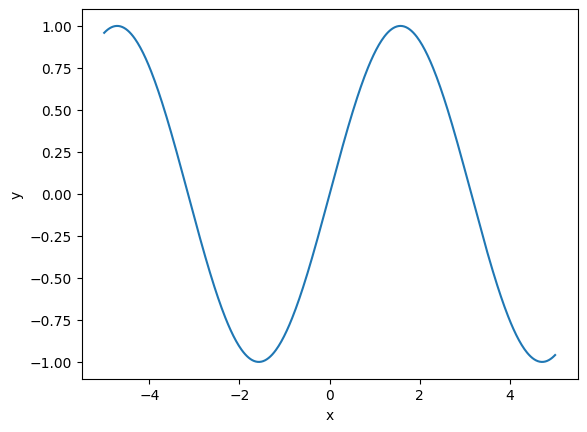

In [4]:
# 2. Create data for interpolation (approximate a function)
''' sin(1/x)
def gen_x_support(min_x, max_x, num_pts):
    _num_pts = int(num_pts/2)
    log_min_x = np.log10(min_x)
    log_max_x = np.log10(max_x)
    pos_x = torch.logspace(log_min_x, log_max_x, _num_pts)
    neg_x = torch.sort(-pos_x)[0]
    return torch.cat([neg_x, pos_x]).reshape(-1, 1)
    
def fun_truth(_x):
    return torch.sin(1./_x)
    
epochs = 10000
min_x, max_x = 1e-5, 2
x = gen_x_support(min_x, max_x, 10000)
x_test = gen_x_support(1e-4, 3., 300) # for later
y = fun_truth(x)
#'''

''' sin(x)/x    
def fun_truth(_x):
    return torch.sin(_x)/_x
    
epochs = 5000
num_hidden = 4 # 3 is good-ish enough
hidden_size = 32

min_x, max_x = -15, 15
x = torch.linspace(min_x, max_x, 500).reshape(-1, 1)
x_test = torch.linspace(min_x*1.5, max_x*1.5, 100).reshape(-1, 1) # for later
y = fun_truth(x)
#'''

#''' sin(x)
def fun_truth(_x, noise_amp = 0.):
    return torch.sin(x) + noise_amp * torch.randn_like(x)
    
epochs = 1000
num_hidden = 3
hidden_size = 32

min_x, max_x = -5, 5
x = torch.linspace(min_x, max_x, 500).reshape(-1, 1)
x_test = torch.linspace(min_x*1.5, max_x*1.5, 100).reshape(-1, 1) # for testing later
y = fun_truth(x)
#'''

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')

In [5]:
# 3. Create model, loss, optimizer
model = MLP(input_size=1,
            num_hidden=num_hidden,
            hidden_size=hidden_size,
           ).to(device)

print(f"Model structure: {model}\n\n")

'''
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")
'''

Model structure: MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)




'\nfor name, param in model.named_parameters():\n    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")\n'

In [6]:
loss_function = nn.MSELoss()  # For regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [7]:
# 4. Train
for epoch in range(epochs):
    optimizer.zero_grad()

    # forward pass
    y_pred = model(x)
    loss = loss_function(y_pred, y)
    
    # backwards pass
    loss.backward()

    # update weights
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

Epoch 0, Loss: 0.520459


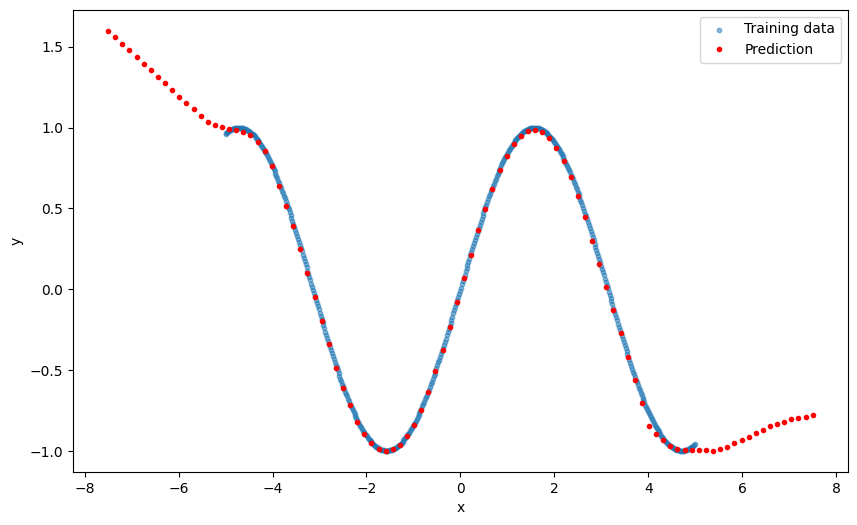

In [8]:
# 5. Visualize interpolation
model.eval()

with torch.no_grad():
    y_pred = model(x_test)
    
plt.figure(figsize=(10, 6))
plt.scatter(x.numpy(), y.numpy(), s=10, alpha=0.5, label='Training data')
plt.plot(x_test.numpy(), y_pred.numpy(), 'r.', linewidth=2, label='Prediction')
plt.xlabel('x')
#plt.xscale('log')
plt.ylabel('y')
plt.legend()